# Explore the Kafka mirror

This notebook reads data from the mirror broker in the Docker Compose setup: which topics it holds, the latest messages in a topic, what arrived recently, a live view of new records, and the consumer group positions MirrorMaker has translated.

If your topics' values are written with a schema registry (Avro or JSON Schema, in the registry's usual wire format), the notebook can decode them into readable records. Point it at the registry in the connection settings; without one, everything works as before.

It only **reads**. It assigns partitions directly instead of joining a consumer group and never commits offsets, so it doesn't create consumer groups on the mirror or disturb MirrorMaker's offset syncing.

**Before you start**

1. The stack is running: `docker compose up -d`
2. There's a user for the notebook. Create one (pick your own password) from the project folder:

   ```bash
   docker compose exec sage-kafka /opt/kafka/bin/kafka-configs.sh --bootstrap-server 127.0.0.1:9095 \
     --alter --entity-type users --entity-name notebook --add-config 'SCRAM-SHA-512=[password=notebook-secret]'
   ```

3. Either set `MIRROR_PASSWORD` in the environment before starting Jupyter, or type the password when the settings cell asks for it.

The notebook connects to the mirror's external listener, `localhost:9094` by default. If Jupyter runs on a different machine than Docker, set `MIRROR_BOOTSTRAP` to `<docker-host>:9094` and make sure the broker advertises that host (`MIRROR_ADVERTISED_HOST` in the Compose setup).

In [1]:
# If pip reports "externally-managed-environment", start Jupyter from a virtual environment instead.
%pip install --quiet "confluent-kafka[avro,json]" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## Connection settings

Defaults match the Compose setup. Override any of them with environment variables: `MIRROR_BOOTSTRAP`, `MIRROR_USERNAME`, `MIRROR_PASSWORD`, and `MIRROR_SECURITY_PROTOCOL` (set it to `PLAINTEXT` for a cluster without authentication).

**Schema registry and deserializers (optional).** Every message's key and value go through a deserializer, chosen with `VALUE_FORMAT` and `KEY_FORMAT`:

- `avro` or `json`: the schema registry's Avro or JSON Schema deserializer. It fetches the schema each record was written with from the registry, so older and newer schema versions both work.
- `string`: plain UTF-8 text, with no registry involved.

Set `SCHEMA_REGISTRY_URL` (no login is used) and values default to `avro`; keys default to `string`. If this machine can't resolve the registry's name (only your internal DNS knows it), also set `SCHEMA_REGISTRY_IP` to the address to use, as `curl --resolve` does; that mapping applies inside this notebook only. You can set all of these as environment variables or type them straight into the cell below.

In [2]:
import os
from getpass import getpass

BOOTSTRAP = os.environ.get("MIRROR_BOOTSTRAP", "localhost:9094")
SECURITY_PROTOCOL = os.environ.get("MIRROR_SECURITY_PROTOCOL", "SASL_PLAINTEXT")
USERNAME = os.environ.get("MIRROR_USERNAME", "notebook")
USES_SASL = SECURITY_PROTOCOL.startswith("SASL")

MIRROR = {
    "bootstrap.servers": BOOTSTRAP,
    "security.protocol": SECURITY_PROTOCOL,
    "client.id": "mirror-notebook",
}
if USES_SASL:
    MIRROR.update({
        "sasl.mechanism": "SCRAM-SHA-512",
        "sasl.username": USERNAME,
        "sasl.password": os.environ.get("MIRROR_PASSWORD") or getpass(f"Password for Kafka user '{USERNAME}': "),
    })

# --- Schema registry and deserializers (optional) ---------------------------------------
# The registry's URL, e.g. "https://registry.example.org". Empty means no registry.
SCHEMA_REGISTRY_URL = os.environ.get("SCHEMA_REGISTRY_URL", "https://schemaregistry.cper.eng.neoninternal.org")
# Only if this machine can't resolve the registry's name: the IP address to use for it.
SCHEMA_REGISTRY_IP = os.environ.get("SCHEMA_REGISTRY_IP", "10.110.51.11")
# Deserializer for message values and keys: "avro" or "json" (through the registry), or "string".
VALUE_FORMAT = os.environ.get("VALUE_FORMAT", "avro" if SCHEMA_REGISTRY_URL else "string")
KEY_FORMAT = os.environ.get("KEY_FORMAT", "string")

for _name, _fmt in (("VALUE_FORMAT", VALUE_FORMAT), ("KEY_FORMAT", KEY_FORMAT)):
    if _fmt not in ("avro", "json", "string"):
        raise ValueError(f"{_name} is {_fmt!r}; use 'avro', 'json' or 'string'.")
    if _fmt != "string" and not SCHEMA_REGISTRY_URL:
        raise ValueError(f"{_name} is {_fmt!r}, which needs SCHEMA_REGISTRY_URL to be set.")

SCHEMA_REGISTRY = None
if SCHEMA_REGISTRY_URL:
    SCHEMA_REGISTRY = {"url": SCHEMA_REGISTRY_URL}
    if SCHEMA_REGISTRY_IP:
        # Like curl --resolve: look the registry's name up as this IP, in this notebook only.
        # Requests still carry the name, so a proxy that routes by name (such as Traefik)
        # and the HTTPS certificate check work as normal. Kafka connections are unaffected.
        import socket
        from urllib.parse import urlparse
        _registry_host = urlparse(SCHEMA_REGISTRY_URL).hostname
        _real_getaddrinfo = getattr(socket, "_real_getaddrinfo", socket.getaddrinfo)
        socket._real_getaddrinfo = _real_getaddrinfo

        def _getaddrinfo(host, *args, **kwargs):
            return _real_getaddrinfo(SCHEMA_REGISTRY_IP if host == _registry_host else host, *args, **kwargs)

        socket.getaddrinfo = _getaddrinfo

print(f"Mirror: {BOOTSTRAP} ({SECURITY_PROTOCOL}" + (f", user {USERNAME})" if USES_SASL else ")"))
print(f"Schema registry: {SCHEMA_REGISTRY_URL or 'not used'}"
      + (f" (reached at {SCHEMA_REGISTRY_IP})" if SCHEMA_REGISTRY_URL and SCHEMA_REGISTRY_IP else ""))
print(f"Deserializers: values {VALUE_FORMAT}, keys {KEY_FORMAT}")

Mirror: localhost:9094 (SASL_PLAINTEXT, user notebook)
Schema registry: https://schemaregistry.cper.eng.neoninternal.org (reached at 10.110.51.11)
Deserializers: values avro, keys string


## Helpers

Run this cell once. The sections below use these functions, and you can call them on any topic.

In [3]:
import json
import time
import uuid

import pandas as pd
from confluent_kafka import (OFFSET_END, Consumer, ConsumerGroupTopicPartitions, KafkaError,
                             KafkaException, TopicPartition)
from confluent_kafka.admin import AdminClient
from confluent_kafka.serialization import MessageField, SerializationContext

pd.set_option("display.max_colwidth", 120)
COLUMNS = ["partition", "offset", "timestamp", "key", "value", "headers"]


def _conf(conf=None):
    settings = dict(conf or MIRROR)
    settings.setdefault("log_level", 3)  # keep librdkafka's informational logs out of the notebook
    settings.setdefault("allow.auto.create.topics", False)  # looking up a mistyped topic must never create it
    return settings


# One admin client and one consumer per cluster, created on first use and reused by every
# helper. Opening and closing a client per call makes librdkafka log harmless but alarming
# "SASL authentication error ... Broker transport failure" lines when a client is closed
# while a background connection is still logging in.
_clients = {}


def _key(conf):
    return tuple(sorted(_conf(conf).items()))


def _admin(conf=None):
    key = ("admin",) + _key(conf)
    if key not in _clients:
        _clients[key] = AdminClient(_conf(conf))
    return _clients[key]


def _consumer(conf=None):
    """A consumer that reads by assigning partitions directly: it never joins a group or commits
    offsets. The client insists on a group.id, but nothing is ever stored under it."""
    key = ("consumer",) + _key(conf)
    if key not in _clients:
        settings = _conf(conf)
        settings.update({
            "group.id": f"notebook-{uuid.uuid4().hex[:8]}",
            "enable.auto.commit": False,
            "enable.partition.eof": True,
            "auto.offset.reset": "earliest",
        })
        _clients[key] = Consumer(settings)
    return _clients[key]


def is_internal(topic):
    """Kafka's own topics (__consumer_offsets, ...) and MirrorMaker's bookkeeping topics
    (heartbeats, and names ending in .internal such as mm2-offsets.primary.internal)."""
    return topic.startswith("_") or topic.endswith(".internal") or topic == "heartbeats"


def _partitions(topic, conf=None):
    meta = _admin(conf).list_topics(topic, timeout=10).topics.get(topic)
    if meta is None or meta.error is not None:
        raise ValueError(f"Topic {topic!r} not found" + (f" ({meta.error})" if meta is not None else ""))
    return sorted(meta.partitions)


def _text(raw):
    """Text stays text; anything that isn't UTF-8 stays as bytes."""
    if raw is None:
        return None
    try:
        return raw.decode("utf-8")
    except UnicodeDecodeError:
        return raw


_registry = {}   # the schema registry client, created on first use
_noted = set()   # (topic, key/value) pairs we've already printed a note about


def _registry_client():
    if not SCHEMA_REGISTRY:
        return None
    if not _registry:
        from confluent_kafka.schema_registry import SchemaRegistryClient
        _registry["client"] = SchemaRegistryClient(SCHEMA_REGISTRY)
    return _registry["client"]


def _make_deserializer(fmt):
    """The schema registry's deserializer for "avro" or "json"; None for plain "string" text."""
    if fmt == "avro":
        from confluent_kafka.schema_registry.avro import AvroDeserializer
        return AvroDeserializer(_registry_client())
    if fmt == "json":
        from confluent_kafka.schema_registry.json_schema import JSONDeserializer
        return JSONDeserializer(None, schema_registry_client=_registry_client())
    return None


DESERIALIZERS = {MessageField.KEY: _make_deserializer(KEY_FORMAT),
                 MessageField.VALUE: _make_deserializer(VALUE_FORMAT)}


def _note(topic, field, text):
    if (topic, field) not in _noted:
        _noted.add((topic, field))
        print(f"{topic} ({field}s): {text}")


def _deserialize(raw, topic, field):
    """Run a message's key or value through its deserializer. Records that can't be
    deserialized are shown as text when they're UTF-8, otherwise as raw bytes."""
    if raw is None:
        return None
    deserializer = DESERIALIZERS[field]
    looks_registered = len(raw) > 5 and raw[0] == 0   # the registry's format: zero byte, schema ID, data
    if deserializer is None:
        if looks_registered:
            _note(topic, field, "these look like schema registry records; set SCHEMA_REGISTRY_URL "
                                "and VALUE_FORMAT/KEY_FORMAT to deserialize them.")
            return raw
        return _text(raw)
    try:
        return deserializer(raw, SerializationContext(topic, field))
    except Exception as e:
        fmt = VALUE_FORMAT if field == MessageField.VALUE else KEY_FORMAT
        _note(topic, field, f"couldn't deserialize as {fmt} ({e}); showing them undecoded.")
        return raw if looks_registered else _text(raw)


def _row(msg):
    _, ts = msg.timestamp()
    return {
        "partition": msg.partition(),
        "offset": msg.offset(),
        "timestamp": ts if ts > 0 else None,
        "key": _deserialize(msg.key(), msg.topic(), MessageField.KEY),
        "value": _deserialize(msg.value(), msg.topic(), MessageField.VALUE),
        "headers": {k: _text(v) for k, v in (msg.headers() or [])} or None,
    }


def _frame(rows):
    df = pd.DataFrame(rows, columns=COLUMNS)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    return df.sort_values(["timestamp", "partition", "offset"], ignore_index=True)


def _read(topic, start, end, conf=None, max_messages=None, timeout_s=120):
    """Read each partition p from offset start[p] up to (not including) end[p]."""
    todo = {p: s for p, s in start.items() if s < end[p]}
    rows = []
    if not todo:
        return _frame(rows)
    consumer = _consumer(conf)
    consumer.assign([TopicPartition(topic, p, s) for p, s in todo.items()])
    try:
        remaining, deadline = set(todo), time.monotonic() + timeout_s
        while remaining and time.monotonic() < deadline:
            for msg in consumer.consume(num_messages=500, timeout=1.0):
                if msg.error():
                    if msg.error().code() == KafkaError._PARTITION_EOF:
                        remaining.discard(msg.partition())
                        continue
                    raise KafkaException(msg.error())
                p = msg.partition()
                if p not in remaining or msg.offset() < todo[p]:
                    continue
                if msg.offset() >= end[p]:
                    remaining.discard(p)
                    continue
                rows.append(_row(msg))
                if msg.offset() >= end[p] - 1:
                    remaining.discard(p)
                if max_messages and len(rows) >= max_messages:
                    remaining.clear()
                    break
        if remaining:
            print(f"Stopped after {timeout_s}s; partitions {sorted(remaining)} weren't read to the end.")
    finally:
        consumer.unassign()
    return _frame(rows)


def watermarks(topic, conf=None):
    """Oldest retained offset (low) and next offset to be written (high) per partition.
    'messages' = high - low, which can overcount slightly on transactional or compacted topics."""
    consumer = _consumer(conf)
    rows = []
    for p in _partitions(topic, conf):
        low, high = consumer.get_watermark_offsets(TopicPartition(topic, p), timeout=10, cached=False)
        rows.append({"partition": p, "low": low, "high": high, "messages": high - low})
    return pd.DataFrame(rows, columns=["partition", "low", "high", "messages"])


def list_topics(include_internal=False, conf=None):
    """Every topic with its partition count and retained messages."""
    meta = _admin(conf).list_topics(timeout=10)
    names = sorted(n for n, t in meta.topics.items() if t.error is None and (include_internal or not is_internal(n)))
    consumer = _consumer(conf)
    rows = []
    for name in names:
        parts = meta.topics[name].partitions
        total = 0
        for p in parts:
            low, high = consumer.get_watermark_offsets(TopicPartition(name, p), timeout=10, cached=False)
            total += high - low
        rows.append({"topic": name, "partitions": len(parts), "messages": total})
    return pd.DataFrame(rows, columns=["topic", "partitions", "messages"])


def peek(topic, n=20, conf=None):
    """The latest n messages across all partitions."""
    wm = watermarks(topic, conf)
    start = {r.partition: max(r.low, r.high - n) for r in wm.itertuples()}
    end = {r.partition: r.high for r in wm.itertuples()}
    return _read(topic, start, end, conf).tail(n).reset_index(drop=True)


def read_all(topic, max_messages=10_000, conf=None):
    """Everything retained in the topic, up to max_messages."""
    wm = watermarks(topic, conf)
    start = {r.partition: r.low for r in wm.itertuples()}
    end = {r.partition: r.high for r in wm.itertuples()}
    return _read(topic, start, end, conf, max_messages=max_messages)


def read_since(topic, minutes=15, max_messages=10_000, conf=None):
    """Messages whose timestamp falls in the last `minutes` minutes."""
    since_ms = int((time.time() - minutes * 60) * 1000)
    wm = watermarks(topic, conf)
    end = {r.partition: r.high for r in wm.itertuples()}
    found = _consumer(conf).offsets_for_times([TopicPartition(topic, p, since_ms) for p in end], timeout=10)
    # An offset of -1 means that partition has nothing that recent.
    start = {tp.partition: (tp.offset if tp.offset >= 0 else end[tp.partition]) for tp in found}
    return _read(topic, start, end, conf, max_messages=max_messages)


def watch(topic, seconds=30, conf=None):
    """Print new messages as they arrive for `seconds` seconds, then return them."""
    consumer = _consumer(conf)
    consumer.assign([TopicPartition(topic, p, OFFSET_END) for p in _partitions(topic, conf)])
    rows = []
    try:
        print(f"Watching {topic} for {seconds}s...")
        deadline = time.monotonic() + seconds
        while time.monotonic() < deadline:
            for msg in consumer.consume(num_messages=100, timeout=0.5):
                if msg.error():
                    if msg.error().code() == KafkaError._PARTITION_EOF:
                        continue  # caught up; nothing new yet
                    raise KafkaException(msg.error())
                row = _row(msg)
                rows.append(row)
                print(f"  partition {row['partition']}  offset {row['offset']}  key={row['key']!r}  value={str(row['value'])[:80]!r}")
    finally:
        consumer.unassign()
    print(f"{len(rows)} new message(s).")
    return _frame(rows)


def expand_json(df, column="value"):
    """Turn JSON-object values, or deserialized records, into one column per field (nested
    fields as parent.child). Other values leave those columns empty."""
    def parse(v):
        if isinstance(v, dict):
            return v
        if isinstance(v, str):
            try:
                obj = json.loads(v)
            except ValueError:
                return {}
            return obj if isinstance(obj, dict) else {}
        return {}
    fields = pd.json_normalize([parse(v) for v in df[column]])
    # A field named like an existing column (key, timestamp, ...) keeps a "value." prefix.
    others = set(df.columns) - {column}
    fields = fields.rename(columns=lambda c: f"{column}.{c}" if c in others else c)
    fields.index = df.index
    return pd.concat([df.drop(columns=[column]), fields], axis=1)

def _as_datetime(values):
    """Datetimes, epoch numbers (seconds, ms, us or ns, judged by size) or date strings,
    as UTC timestamps."""
    v = pd.Series(values).dropna()
    if v.empty:
        return pd.Series(dtype="datetime64[ns, UTC]")
    if pd.api.types.is_datetime64_any_dtype(v):
        return pd.to_datetime(v, utc=True)
    if pd.api.types.is_numeric_dtype(v):
        biggest = v.abs().max()
        unit = "ns" if biggest > 1e17 else "us" if biggest > 1e14 else "ms" if biggest > 1e11 else "s"
        return pd.to_datetime(v, unit=unit, utc=True)
    return pd.to_datetime(v, utc=True, errors="coerce", format="mixed")


def time_range(df, field="readout_time"):
    """Earliest and latest value of a time field inside the messages (found at any nesting
    level), shown next to the Kafka timestamps of the same messages."""
    if df.empty:
        print("No messages to look at.")
        return pd.DataFrame()
    flat = expand_json(df)
    columns = [c for c in flat.columns if c == field or c.endswith("." + field)]
    if not columns:
        print(f"No {field!r} field in these messages. Are the values deserialized (VALUE_FORMAT)?")
        return pd.DataFrame()
    rows = []
    for name, times in [(c, _as_datetime(flat[c])) for c in columns] + [("timestamp (Kafka)", df["timestamp"].dropna())]:
        rows.append({"field": name, "messages": int(times.notna().sum()),
                     "min": times.min(), "max": times.max(), "span": times.max() - times.min()})
    return pd.DataFrame(rows).set_index("field")

def consumer_groups(conf=None):
    """Consumer groups with their committed offsets and lag. Groups that MirrorMaker syncs
    from the source appear here with offsets translated to the mirror's numbering."""
    admin, consumer = _admin(conf), _consumer(conf)
    listing = admin.list_consumer_groups(request_timeout=10).result()
    rows = []
    for group in sorted(listing.valid, key=lambda g: g.group_id):
        result = admin.list_consumer_group_offsets([ConsumerGroupTopicPartitions(group.group_id)], request_timeout=10)
        for tp in result[group.group_id].result().topic_partitions or []:
            if tp.offset < 0:
                continue
            _, high = consumer.get_watermark_offsets(TopicPartition(tp.topic, tp.partition), timeout=10, cached=False)
            rows.append({"group": group.group_id, "state": str(group.state).split(".")[-1],
                         "topic": tp.topic, "partition": tp.partition,
                         "committed": tp.offset, "end": high, "lag": max(high - tp.offset, 0)})
    return pd.DataFrame(rows, columns=["group", "state", "topic", "partition", "committed", "end", "lag"])


def registry_subjects():
    """Subjects in the schema registry, with each one's latest version, schema ID and type."""
    client = _registry_client()
    columns = ["subject", "version", "schema_id", "type"]
    if client is None:
        print("No schema registry configured (set SCHEMA_REGISTRY_URL).")
        return pd.DataFrame(columns=columns)
    rows = []
    for subject in sorted(client.get_subjects()):
        latest = client.get_latest_version(subject)
        rows.append({"subject": subject, "version": latest.version, "schema_id": latest.schema_id,
                     "type": latest.schema.schema_type or "AVRO"})
    return pd.DataFrame(rows, columns=columns)


print("Helpers ready.")

Helpers ready.


## 1. Topics on the mirror

Your mirrored topics, with partition counts and how many messages each holds. Pass `include_internal=True` to also see Kafka's and MirrorMaker's own topics.

In [4]:
list_topics()

,topic,partitions,messages
0,reading.sensor.csat3,1,0
1,reading.sensor.csat3b,1,3572692
2,reading.sensor.li7200_raw,1,3572559


## 2. Pick a topic

Set `TOPIC` to one of the topics above. The table shows, per partition, the oldest retained offset (`low`), the next offset to be written (`high`), and the difference.

In [ ]:
TOPIC = os.environ.get("NOTEBOOK_TOPIC", "reading.sensor.li7200_raw")
TOPIC = os.environ.get("NOTEBOOK_TOPIC", "reading.sensor.csat3b")
watermarks(TOPIC)

,partition,low,high,messages
0,0,0,3572692,3572692


## 3. Latest messages

In [6]:
latest = peek(TOPIC, n=100)
latest

,partition,offset,timestamp,key,value,headers
0,0,3572592,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:33+00:00, 'ux_wind_speed': -1.21364998817...",None
1,0,3572593,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:33.050000+00:00, 'ux_wind_speed': -1.0768...",None
2,0,3572594,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:33.100000+00:00, 'ux_wind_speed': -1.0372...",None
3,0,3572595,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:33.150000+00:00, 'ux_wind_speed': -1.0716...",None
4,0,3572596,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:33.200000+00:00, 'ux_wind_speed': -1.1186...",None
...,...,...,...,...,...,...
95,0,3572687,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:37.750000+00:00, 'ux_wind_speed': -1.3448...",None
96,0,3572688,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:37.800000+00:00, 'ux_wind_speed': -1.4942...",None
97,0,3572689,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:37.850000+00:00, 'ux_wind_speed': -1.4365...",None
98,0,3572690,2026-10-07 20:23:48.277000+00:00,59483,"{'source_id': '59483', 'site_id': 'CPER', 'readout_time': 2026-10-07 20:23:37.900000+00:00, 'ux_wind_speed': -1.4923...",None


If the values are JSON objects, or records decoded through the schema registry, this spreads their fields into columns:

In [7]:
df = expand_json(latest)
df

,partition,offset,timestamp,key,headers,source_id,site_id,readout_time,ux_wind_speed,uy_wind_speed,uz_wind_speed,sonic_temperature,diagnostic,pitch,roll,board_temp,board_humidity
0,0,3572592,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:33+00:00,-1.213650,2.984586,-0.077828,24.297609,0,1.969198,1.749217,33.375,29.6138
1,0,3572593,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:33.050000+00:00,-1.076834,3.146129,-0.100589,24.231380,0,1.969198,1.749217,33.375,29.6138
2,0,3572594,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:33.100000+00:00,-1.037263,3.163952,-0.151679,24.125240,0,1.969198,1.749217,33.375,29.6138
3,0,3572595,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:33.150000+00:00,-1.071649,3.237351,-0.208816,24.120150,0,1.969198,1.749217,33.375,29.6138
4,0,3572596,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:33.200000+00:00,-1.118654,3.197684,-0.217742,24.115570,0,1.969198,1.749217,33.375,29.6138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,3572687,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:37.750000+00:00,-1.344863,2.622068,-0.135453,24.002689,0,1.969198,1.749217,33.375,29.6138
96,0,3572688,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:37.800000+00:00,-1.494236,2.526957,-0.183264,23.977200,0,1.969198,1.749217,33.375,29.6138
97,0,3572689,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:37.850000+00:00,-1.436505,2.531736,-0.187297,24.037840,0,1.969198,1.749217,33.375,29.6138
98,0,3572690,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,2026-10-07 20:23:37.900000+00:00,-1.492379,2.641589,-0.290230,23.986019,0,1.969198,1.749217,33.375,29.6138


In [8]:
df['readout_time'] = pd.to_datetime(df['readout_time'])
df = df.sort_values('readout_time').set_index('readout_time')
site_id = df['site_id'].unique()[0]
df

,partition,offset,timestamp,key,headers,source_id,site_id,ux_wind_speed,uy_wind_speed,uz_wind_speed,sonic_temperature,diagnostic,pitch,roll,board_temp,board_humidity
readout_time,,,,,,,,,,,,,,,,
2026-10-07 20:23:33+00:00,0,3572592,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.213650,2.984586,-0.077828,24.297609,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:33.050000+00:00,0,3572593,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.076834,3.146129,-0.100589,24.231380,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:33.100000+00:00,0,3572594,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.037263,3.163952,-0.151679,24.125240,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:33.150000+00:00,0,3572595,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.071649,3.237351,-0.208816,24.120150,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:33.200000+00:00,0,3572596,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.118654,3.197684,-0.217742,24.115570,0,1.969198,1.749217,33.375,29.6138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-07 20:23:37.750000+00:00,0,3572687,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.344863,2.622068,-0.135453,24.002689,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:37.800000+00:00,0,3572688,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.494236,2.526957,-0.183264,23.977200,0,1.969198,1.749217,33.375,29.6138
2026-10-07 20:23:37.850000+00:00,0,3572689,2026-10-07 20:23:48.277000+00:00,59483,None,59483,CPER,-1.436505,2.531736,-0.187297,24.037840,0,1.969198,1.749217,33.375,29.6138


<Axes: title={'center': 'Sage Kafka Mirror: reading.sensor.csat3b, site: CPER'}, xlabel='readout_time'>

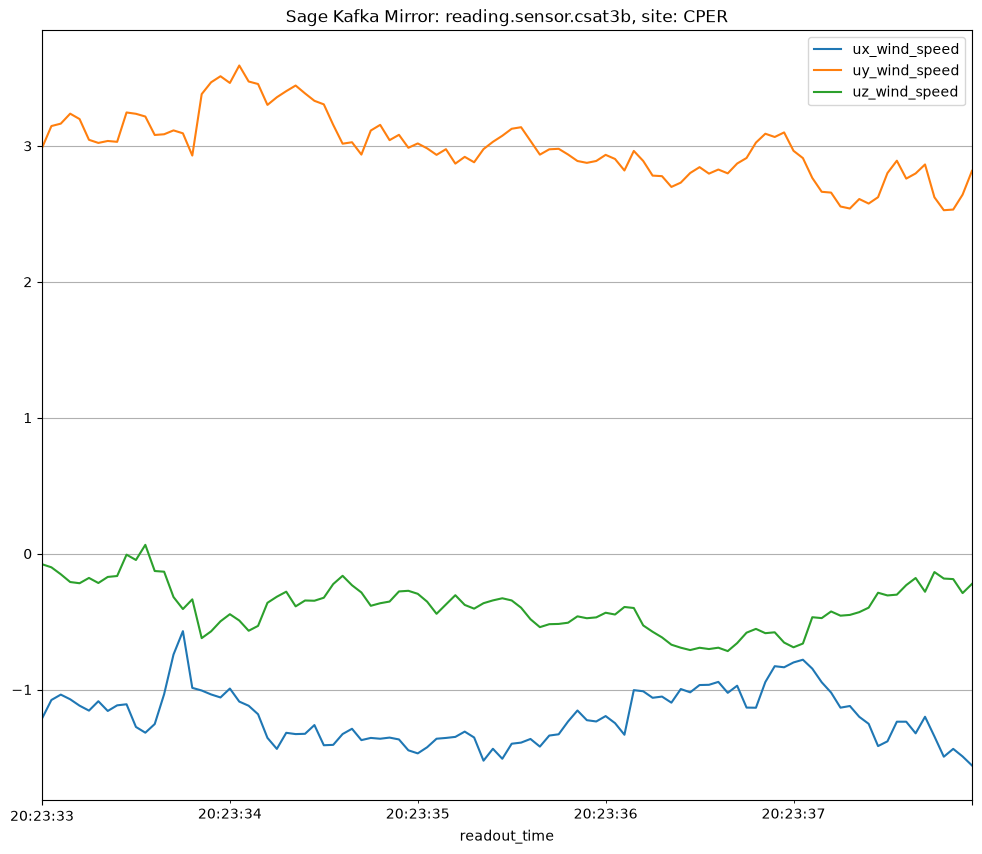

In [9]:
df.plot(y=["ux_wind_speed","uy_wind_speed","uz_wind_speed"],
        title=f"Sage Kafka Mirror: {TOPIC}, site: {site_id}",
        figsize=(12,10),grid=True)

## 4. What arrived recently

Messages from the last 15 minutes by record timestamp, and how many arrived each minute. MirrorMaker keeps the original timestamps, so these reflect when records were produced on the source.

In [10]:
recent = read_since(TOPIC, minutes=15, max_messages=50_000)
print(f"{len(recent)} messages in the last 15 minutes")
recent.set_index("timestamp").resample("1min").size().to_frame("messages")

17980 messages in the last 15 minutes


,messages
timestamp,
2026-10-07 20:09:00+00:00,1230
2026-10-07 20:10:00+00:00,1240
2026-10-07 20:11:00+00:00,1230
2026-10-07 20:12:00+00:00,1220
2026-10-07 20:13:00+00:00,1220
2026-10-07 20:14:00+00:00,1230
2026-10-07 20:15:00+00:00,1220
2026-10-07 20:16:00+00:00,820
2026-10-07 20:17:00+00:00,1220


The earliest and latest `readout_time` in those messages, next to their Kafka timestamps. `readout_time` comes from inside each record (when the reading was taken), while the Kafka timestamp is when the record was produced, so comparing the two shows how long readings take to reach Kafka. Pass another field name to `time_range` to do the same for it.

In [11]:
time_range(recent, "readout_time")

,messages,min,max,span
field,,,,
readout_time,17980,2026-10-07 20:08:39+00:00,2026-10-07 20:23:37.950000+00:00,0 days 00:14:58.950000
timestamp (Kafka),17980,2026-10-07 20:09:10.113000+00:00,2026-10-07 20:23:48.277000+00:00,0 days 00:14:38.164000


## 5. Watch new messages arrive

Prints each new message for 30 seconds. Produce something on the source while this runs to see replication happen; with the throwaway test source from the README, rerun its producer command in a terminal.

In [12]:
live = watch(TOPIC, seconds=60)

Watching reading.sensor.csat3b for 60s...
  partition 0  offset 3572692  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572693  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572694  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572695  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572696  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572697  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 3572698  key='59483'  value="{'source_id': '59483', 'site_id': 'CPER', 'readout_time': datetime.datetime(2026"
  partition 0  offset 35726